In [1]:
# Set a random seed for reproducibility in TensorFlow
import os
import random
import tensorflow as tf
import numpy as np

def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [3]:
# Load LMSuccSite model
from keras.layers import Input, Dense, Dropout
from keras.models import Model
from keras.layers import Concatenate, Dense
from keras.models import Model
from keras.layers import Embedding, Conv2D, MaxPooling2D, Flatten, Lambda
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy


def create_conv_branch(input_shape_conv):
    conv_input = Input(shape=input_shape_conv, name='conv_input')

    # Embedding layer
    x = Embedding(input_dim=256, output_dim=21, name='embedding', input_length=input_shape_conv[0])(conv_input)

    x = Lambda(lambda x: tf.expand_dims(x, 3))(x)

    # Convolutional layers
    x = Conv2D(32, kernel_size=(17, 3), activation='relu',
               kernel_initializer='he_normal', padding='VALID')(x)
    x = Dropout(0.2)(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Flatten()(x)

    x = Dense(16, activation='relu', kernel_initializer='he_normal')(x)
    x = Dropout(0.2)(x)

    # Output of convolutional branch
    conv_output = Dense(16, activation='relu', name='conv_output')(x)

    conv_output = Dense(1, activation='sigmoid')(conv_output)

    model = Model(inputs=conv_input, outputs=conv_output, name='conv_branch')

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

    return model

def create_ann_branch(input_shape_ann):
    ann_input = Input(shape=(input_shape_ann,), name='ann_input')

    x = Dense(256, activation='relu')(ann_input)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.4)(x)

    # Output of ANN branch
    ann_output = Dense(1, activation='sigmoid', name='ann_output')(x)

    model = Model(inputs=ann_input, outputs=ann_output, name='ann_branch')

    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

    return model

def create_combined_model(conv_branch, ann_branch):
    # Freeze the branches if you don't want to train them initially
    conv_branch.trainable = False
    ann_branch.trainable = False

    # Define inputs
    conv_input = conv_branch.input
    ann_input = ann_branch.input

    # Get outputs from the branches
    conv_output = conv_branch.get_layer(index=6).output
    ann_output = ann_branch.get_layer(index=4).output

    # Concatenate the outputs
    combined = Concatenate()([conv_output, ann_output])

    # Add combined layers
    x = Dense(16, activation='relu')(combined)
    x = Dense(4, activation='relu')(x)
    output = Dense(1, activation='sigmoid', name='output')(x)

    # Define the combined model
    combined_model = Model(inputs=[conv_input, ann_input], outputs=output, name='combined_model')

    # Compile the combined model
    combined_model.compile(optimizer=Adam(learning_rate=0.001),
                           loss=BinaryCrossentropy(),
                           metrics=['accuracy'])

    return combined_model


conv_branch = create_conv_branch((33,))
ann_branch = create_ann_branch(1024)
LMSuccSite = create_combined_model(conv_branch, ann_branch)

LMSuccSite.summary()

Model: "combined_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ conv_input          │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 21)    │      5,376 │ conv_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 33, 21, 1) │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ann_input           │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 17, 19,    │      1,664 │ lambda_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 256)       │    262,400 │ ann_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 17, 19,    │          0 │ conv2d_1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 8, 9, 32)  │          0 │ dropout_4[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 128)       │     32,896 │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 2304)      │          0 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 2432)      │          0 │ flatten_1[0][0],  │
│ (Concatenate)       │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │     38,928 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 4)         │         68 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │          5 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 341,337 (1.30 MB)

 Trainable params: 39,001 (152.35 KB)

 Non-trainable params: 302,336 (1.15 MB)

In [4]:
# Load ResLysEmbed model
import tensorflow as tf
from keras.layers import Input, Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Concatenate, Lambda
from keras.models import Model
from keras.optimizers import Adam
from keras.losses import BinaryCrossentropy
from keras.initializers import Constant


def residual_block(input_tensor, filters):
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(input_tensor)
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(x)    
    x = Concatenate()([x, input_tensor])  # Skip connection
    return x

def build_resnet_model(input_shape_conv, input_shape_ann):
    # Conv1D branch for sequence data
    conv_input = Input(shape=input_shape_conv)
    x_conv = Embedding(input_dim=21, output_dim=21, name='embedding', trainable=True)(conv_input)

    # Apply Residual blocks
    x_conv = residual_block(x_conv, 32)
    x_conv = MaxPooling1D(pool_size=2)(x_conv)
    x_conv = residual_block(x_conv, 64)
    x_conv = MaxPooling1D(pool_size=2)(x_conv)
    x_conv = Flatten()(x_conv)

    # Dense layer for sequence features
    x_conv = Dense(32, activation='relu')(x_conv)
    x_conv = Dropout(0.3)(x_conv)

    # ANN branch for prot_t5 embeddings
    ann_input = Input(shape=(input_shape_ann,))
    x_ann = Dense(32, activation='relu')(ann_input)
    x_ann = Dropout(0.3)(x_ann)

    # Concatenate Conv1D (ResNet) and ANN branches
    combined = Concatenate()([x_conv, x_ann])

    # Output layer
    x = Dense(32, activation='relu')(combined)
    x = Dropout(0.3)(x)
    output_layer = Dense(1, activation='sigmoid')(x)

    # Build model
    model = Model(inputs=[conv_input, ann_input], outputs=output_layer)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss=BinaryCrossentropy(),
                  metrics=['accuracy'])

    return model


set_seed(4)

# Define the model with Conv1D input shape (33,) and ANN input shape 1024
ResLysEmbed = build_resnet_model((33,), 1024)

ResLysEmbed.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 33)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 33, 21)    │        441 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 33, 32)    │      2,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 33, 32)    │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 33, 53)    │          0 │ conv1d_1[0][0],   │
│ (Concatenate)       │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 16, 53)    │          0 │ concatenate_2[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 64)    │     10,240 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 16, 64)    │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 117)   │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 8, 117)    │          0 │ concatenate_3[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 936)       │          0 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1024)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │     29,984 │ flatten_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 32)        │     32,800 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 32)        │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense_13[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 64)        │          0 │ dropout_8[0][0],  │
│ (Concatenate)       │                   │            │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │      2,080 │ concatenate_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 32)        │          0 │ dense_14[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 1)         │         33 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 93,082 (363.60 KB)

 Trainable params: 93,082 (363.60 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Load Weights for LMSuccSite and ResLysEmbed
LMSuccSite.load_weights('Models/LMSuccSite.weights.h5')
ResLysEmbed.load_weights('Models/Weights/res_model.weights.h5')

In [6]:
# Load Train and Test data
import numpy as np
import pandas as pd


# --- Sequence to integer encoding ---
# Create a dictionary to map amino acids to integers
amino_acids = 'ACDEFGHIKLMNPQRSTVWY-'
aa_to_int = {aa: i for i, aa in enumerate(amino_acids)}

# --- Load and process train data ---
train = pd.read_csv('DbPtm/Train/succinylation_benchmark.csv')
print(train.shape)

# Remove entries with sequences that contain characters not in the amino_acids set
train = train[train['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]
print(train.shape)

X_train_embeddings = train['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split(',')]))
X_train_embeddings = np.stack(X_train_embeddings.values)
X_train = train['sequence'].values
y_train = train['label'].values
X_train_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_train])

# Print shapes
print("X_train_embeddings shape:", X_train_embeddings.shape)
print("X_train_num shape:", X_train_num.shape)
print("y_train shape:", y_train.shape)


# --- Load and process test data ---
test = pd.read_csv('DbPtm/dbptm_benchmark_filtered.csv')
# test = pd.read_csv('Test Data/test_t5_pssm.csv')
print(test.shape)

test = test[test['sequence'].apply(lambda x: all(aa in amino_acids for aa in x))]

X_test_embeddings = test['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split(',')]))
# X_test_embeddings = test['embedding'].apply(lambda x: np.array([float(i) for i in x.strip('[]').split()]))

X_test_embeddings = np.stack(X_test_embeddings.values)
X_test = test['sequence'].values
y_test = test['label'].values



# Convert the sequences to a numerical format and convert to numpy arrays
X_test_num = np.array([[aa_to_int[aa] for aa in seq] for seq in X_test])

#print shapes
print("X_test_embeddings shape:", X_test_embeddings.shape)
print("X_test_num shape:", X_test_num.shape)
print("y_test shape:", y_test.shape)



(34650, 5)
(34646, 5)
X_train_embeddings shape: (34646, 1024)
X_train_num shape: (34646, 33)
y_train shape: (34646,)
(4210, 5)
X_test_embeddings shape: (4210, 1024)
X_test_num shape: (4210, 33)
y_test shape: (4210,)


In [8]:
# Evaluation function
from sklearn.metrics import accuracy_score, matthews_corrcoef, roc_auc_score, average_precision_score
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
def evaluate_model(model, X_val = None, X_val_pt5 = None, X_val_PSSM = None, y_val = None, print_metrics=True):
    y_true = y_val
    # Predict probabilities (or logits if using `from_logits=True`).
    if X_val_pt5 is None:
        y_pred_probs = model.predict(X_val)
    elif X_val is None:
        y_pred_probs = model.predict(X_val_pt5)
    elif X_val_PSSM is None:
        y_pred_probs = model.predict([X_val, X_val_pt5])
    else:
        y_pred_probs = model.predict([X_val, X_val_pt5, X_val_PSSM])

    # Convert probabilities/logits to binary predictions (threshold = 0.5).
    y_pred = (y_pred_probs > 0.5).astype(int)

    # If y_true is one-hot encoded, convert it to binary format
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:  # Check if y_true is one-hot encoded
        y_true = np.argmax(y_true, axis=1)  # Convert one-hot encoded y_true to binary labels

    # Ensure y_pred is also 1D
    if len(y_pred.shape) > 1 and y_pred.shape[1] > 1:
        y_pred = np.argmax(y_pred, axis=1)  # Convert y_pred to binary labels if necessary

    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc = roc_auc_score(y_true, y_pred_probs)
    auprc = average_precision_score(y_true, y_pred_probs)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Compute Specificity
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp)

    # Print the results
    if print_metrics:
        print(f'Accuracy: {accuracy:.4f}')
        print(f'MCC: {mcc:.4f}')
        print(f'AUC: {auc:.4f}')
        print(f'AUPRC: {auprc:.4f}')
        print(f'Precision: {precision:.4f}')
        print(f'Recall: {recall:.4f}')
        print(f'Specificity: {specificity:.4f}')
        print(f'F1 Score: {f1:.4f}')

    return accuracy, mcc, auc, auprc, precision, recall, specificity, f1

In [11]:
# Evaluate the models
evaluate_model(ResLysEmbed, X_test_num, X_test_embeddings, X_val_PSSM= None, y_val=y_test, print_metrics=True)
evaluate_model(LMSuccSite, X_test_num, X_test_embeddings, X_val_PSSM= None, y_val=y_test, print_metrics=True)

132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.7264
MCC: 0.4444
AUC: 0.7889
AUPRC: 0.7233
Precision: 0.7313
Recall: 0.6228
Specificity: 0.8116
F1 Score: 0.6727
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.7050
MCC: 0.4003
AUC: 0.7671
AUPRC: 0.7037
Precision: 0.7097
Recall: 0.5865
Specificity: 0.8025
F1 Score: 0.6423


(0.7049881235154394,
 0.4003090653927157,
 0.7670616932712353,
 0.7037048339787835,
 0.7097390197326544,
 0.5865334034718569,
 0.8025119099177133,
 0.6422811059907834)

In [ ]:
# Load ResNet branch model
import tensorflow as tf
from tensorflow.keras import layers, models
import shap
import numpy as np
def residual_block(input_tensor, filters):
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(input_tensor)
    x = Conv1D(filters, kernel_size=3, activation='relu', padding='same')(x)    
    x = Concatenate()([x, input_tensor])  # Skip connection
    return x
# Define the Conv branch model separately
def create_conv_branch(input_shape):
    input_layer = layers.Input(shape=input_shape)
    x = layers.Embedding(input_dim=21, output_dim=21)(input_layer)
    x = residual_block(x, 32)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs=input_layer, outputs=x)

# Specify the input shape for your Conv branch
input_shape_conv = (33,)  # Adjust this based on your data
ResNet_branch = create_conv_branch(input_shape_conv)

ResNet_branch.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [14]:
ResNet_branch.fit(X_train_num, y_train, epochs=100, batch_size=64, validation_split=0.2, verbose=1)
evaluate_model(ResNet_branch, X_test_num, y_val=y_test, print_metrics=True)

Epoch 1/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7435 - loss: 0.5392 - val_accuracy: 0.4342 - val_loss: 0.9138
Epoch 2/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7442 - loss: 0.5361 - val_accuracy: 0.4538 - val_loss: 0.8756
Epoch 3/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7445 - loss: 0.5332 - val_accuracy: 0.4593 - val_loss: 0.8781
Epoch 4/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7438 - loss: 0.5306 - val_accuracy: 0.4564 - val_loss: 0.8820
Epoch 5/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7470 - loss: 0.5277 - val_accuracy: 0.4561 - val_loss: 0.8818
Epoch 6/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7456 - loss: 0.5260 - val_accuracy: 0.4498 - val_loss: 0.8815
Epoch 7/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7484 - loss: 0.5245 - val_accuracy: 0.4518 - val_loss: 0.8898
Epoch 8/100
434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7500 - loss: 0.5198 - val_accu

(0.7665083135391924,
 0.5805426074391632,
 0.8479959374940909,
 0.760082121140614,
 0.6732075471698113,
 0.9384534455549711,
 0.6249458640103941,
 0.7840035157108328)

In [ ]:
# Calculate distances function
from Bio.PDB import PDBParser
from Bio import SeqIO
import numpy as np

# Function to extract the sequence from a FASTA file
def get_sequence(protein_id, site, fasta_file, window_size=16, pad_char='-'):
    with open(fasta_file) as fasta:
        for record in SeqIO.parse(fasta, 'fasta'):
            if protein_id in record.id:
                seq = record.seq
                site = int(site)

                # Calculate start and end indices
                start = max(0, site - window_size - 1)
                end = min(len(seq), site + window_size)

                # Extract the sequence
                extracted_seq = str(seq[start:end])

                # Calculate padding needed on the left and right
                left_padding = max(0, window_size - site + 1)
                right_padding = max(0, (site + window_size) - len(seq))

                # Add padding if necessary
                padded_seq = (pad_char * left_padding) + extracted_seq + (pad_char * right_padding)

                return padded_seq
    return None

# Function to calculate distances within a 33-residue window
def calculate_distances(protein_id, site, pdb_file, window_size=16):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(protein_id, pdb_file)
    
    # Store CA atom coordinates for the residues in the specified window
    ca_coords = []
    target_coord = None
    for model in structure:
        for chain in model:
            residues = list(chain.get_residues())
            
            # Find the index of the target site in residues list
            target_index = None
            for i, residue in enumerate(residues):
                if residue.get_id()[1] == site:
                    target_index = i
                    break
            
            if target_index is not None:
                # Calculate the window boundaries
                start = max(0, target_index - window_size)
                end = min(len(residues), target_index + window_size + 1)
                
                # Collect CA atom coordinates within the window
                for i in range(start, end):
                    residue = residues[i]
                    if "CA" in residue:
                        ca_atom = residue["CA"]
                        ca_coords.append((residue.get_id()[1], ca_atom.get_coord()))
                    
                    # Identify the target site's CA coordinates
                    if i == target_index:
                        target_coord = ca_atom.get_coord()
                break

    # Calculate distances from target to each residue within the window
    distances = {}
    if target_coord is not None:
        for res_id, coord in ca_coords:
            distance = np.linalg.norm(target_coord - coord)
            distances[res_id] = distance

    return distances

# Usage of functions
protein_id = test['protein_id'].values[0]
site = int(test['site'].values[0])

print("Protein ID:", protein_id, "Site:", site)

# File paths
fasta_file = 'DbPtm/dbptm_test_filtered.fasta'
pdb_file = f'PDB files/{protein_id}.pdb'

# Get the sequence from FASTA file
sequence = get_sequence(protein_id, site, fasta_file)
print("Extracted sequence:", sequence)
print("Expected sequence from train data:", test['sequence'].values[0])

# Calculate distances
distances = calculate_distances(protein_id, site, pdb_file)
print("Distances from target site to residues in 33-residue window:", distances)

Protein ID: 40C1_ORYSJ Site: 95
Extracted sequence: GNPAFALVNKATGLAIKHSLGQGHPVKLAPFNP
Expected sequence from train data: GNPAFALVNKATGLAIKHSLGQGHPVKLAPFNP
Distances from target site to residues in 33-residue window: {79: 20.37349, 80: 18.148289, 81: 16.714031, 82: 13.108071, 83: 11.456289, 84: 8.707904, 85: 8.702798, 86: 9.715639, 87: 11.509782, 88: 15.179467, 89: 16.239388, 90: 13.64892, 91: 12.514717, 92: 8.871235, 93: 6.12223, 94: 3.8327942, 95: 0.0, 96: 3.8187633, 97: 6.5592847, 98: 10.178929, 99: 11.526134, 100: 13.777099, 101: 14.413576, 102: 11.51062, 103: 9.67087, 104: 6.0147605, 105: 4.8344393, 106: 5.35699, 107: 6.094409, 108: 9.224926, 109: 9.446817, 110: 12.146871, 111: 14.061588}


In [ ]:
import pickle
import shap
import numpy as np
import matplotlib.pyplot as plt

# Select a single sample for SHAP analysis
amino_acids = 'ACDEFGHIKLMNPQRSTVWY-'
aa_to_int = {aa: i for i, aa in enumerate(amino_acids)}
# Initialize KernelExplainer for SHAP values
shap_explainer = shap.KernelExplainer(ResNet_branch.predict, X_train_num[:10])

# Initialize lists to store SHAP values, distances, and feature names for all proteins
all_shap_values = []

for i in range (len(test)):

    data = test['sequence'].values[i]
    data = [aa_to_int[aa] for aa in data]
    data = np.array(data)
    shap_values = shap_explainer.shap_values(data)
    shap_values = np.abs(np.array(shap_values).squeeze())  # Take absolute SHAP values


    # Reshape if needed and create a SHAP Explanation object
    shap_values = shap_values.squeeze()  # Ensure correct shape for visualization
    all_shap_values.append(shap_values)
    print(f"Processed SHAP values for protein {i+1}/{len(test)}")

base_values = shap_explainer.expected_value  # Use model's expected output as base

feature_names = ['embedding_pos_' + str(i) for i in range(33)]

# Create the SHAP Explanation object without flattening
shap_values = shap.Explanation(
    values=all_shap_values,
    base_values=base_values,
    feature_names=feature_names
)

with open('SHAP/sequence_shap_values_DBPTM.pkl', 'wb') as f:
    pickle.dump(shap_values, f) 


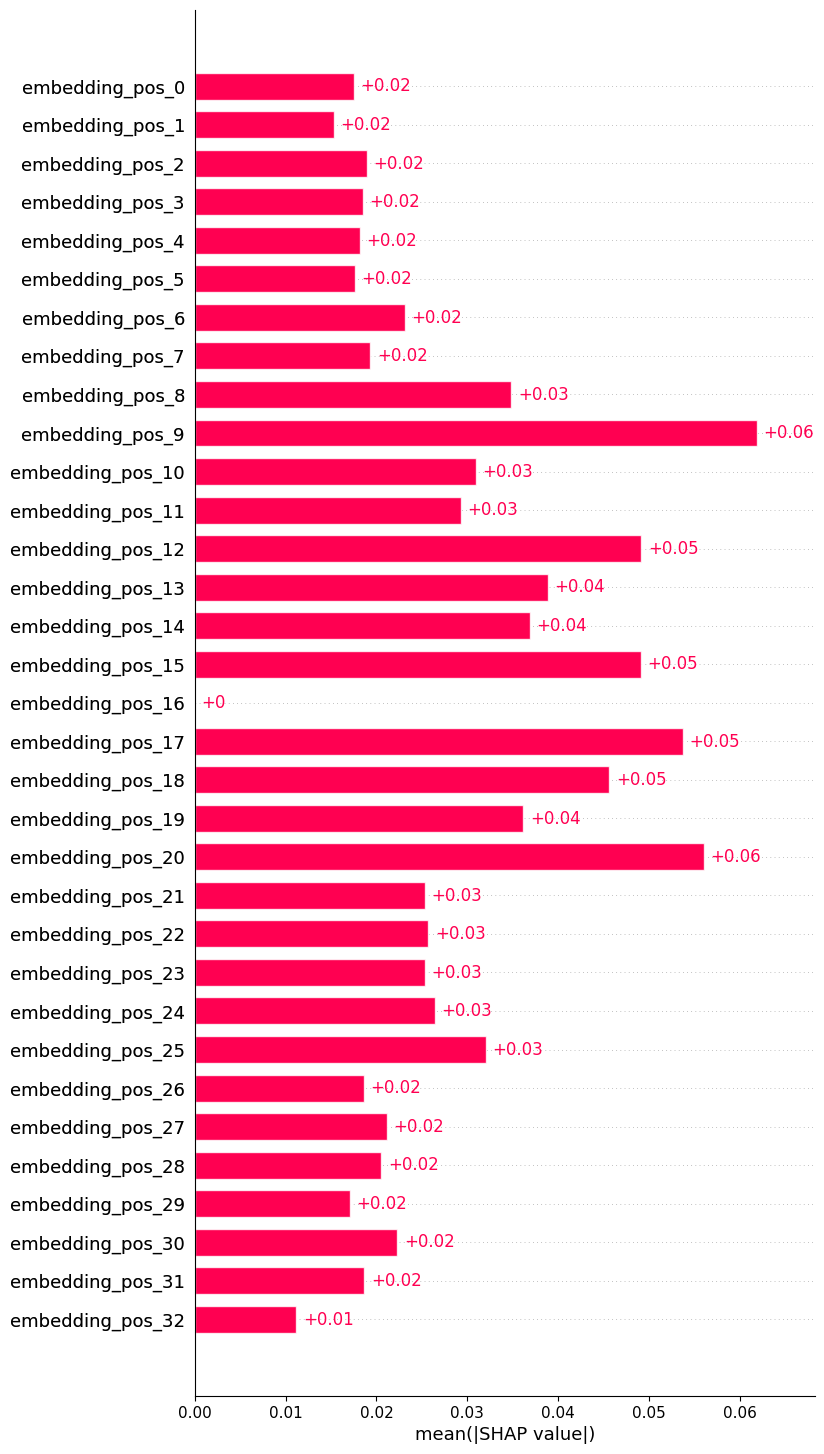

In [ ]:
with open('SHAP/sequence_shap_values_DBPTM.pkl', 'rb') as f:
    shap_values = pickle.load(f)
    
feature_names = ['embedding_pos_' + str(i) for i in range(33)]

# Visualize SHAP values as a bar plot in original order
ordering = np.arange(len(feature_names))  # Preserve original order
shap.plots.bar(shap_values, max_display=len(feature_names), order=ordering)
plt.show()
plt.close()

In [27]:
import pickle
import shap
import numpy as np

# Select a single sample for SHAP analysis
amino_acids = 'ACDEFGHIKLMNPQRSTVWY-'
aa_to_int = {aa: i for i, aa in enumerate(amino_acids)}

# Initialize KernelExplainer for SHAP values
shap_explainer = shap.KernelExplainer(ResNet_branch.predict, X_train_num[:10])

# Initialize list to store SHAP values and distances for all proteins
shap_and_distances = []

# Loop through proteins and compute SHAP values
for i in range(len(test)):
    try:
        protein_id = test['protein_id'].values[i]
        site = int(test['site'].values[i])
        
        # File paths
        pdb_file = f'PDB files/{protein_id}.pdb'
        distances = calculate_distances(protein_id, site, pdb_file)
    except:
        continue

    if len(distances) != 33:
        continue
    data = test['sequence'].values[i]
    data = [aa_to_int[aa] for aa in data]
    data = np.array(data)
    shap_values = shap_explainer.shap_values(data)
    shap_values = np.abs(np.array(shap_values).squeeze())  # Take absolute SHAP values

    # Ensure the order of distances aligns with shap_values
    distance_values = np.array([distances[i] for i in sorted(distances.keys())])
    # Scale the distances
    # distance_values = (distance_values - np.min(distance_values)) / (np.max(distance_values) - np.min(distance_values))

    # Store SHAP values and distances
    shap_and_distances.append((shap_values, distance_values))
    print(f"Processed SHAP values for protein {i+1}/{len(test)}")

# Save SHAP values and distances to a file
with open('SHAP/shap_and_distances_DBPTM.pkl', 'wb') as f:
    pickle.dump(shap_and_distances, f)

print("SHAP values and distances saved.")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 1/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 2/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Processed SHAP values for protein 4/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 5/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 6/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 7/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 8/4210
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Processed SHAP values for protein 9/4210
1/

Average number of residues in each bin: [ 2.0005349   4.73976999  6.36079166 11.22947312  6.21850762  1.45092271]


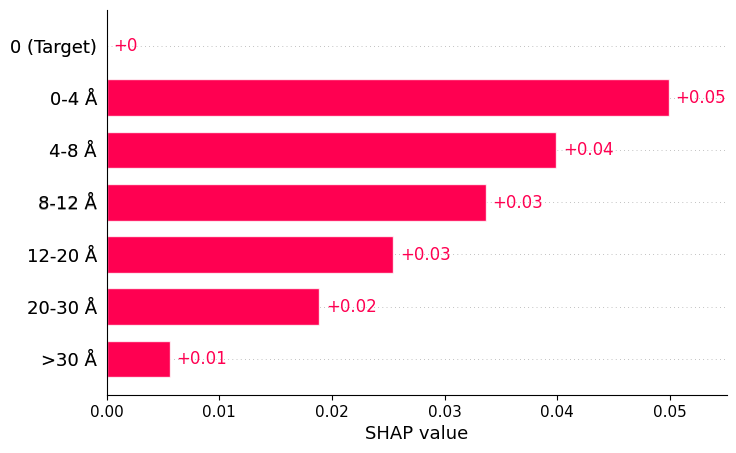

In [31]:
import pickle
import numpy as np
import shap
import matplotlib.pyplot as plt

# Load SHAP values and distances
with open('SHAP/shap_and_distances_DBPTM.pkl', 'rb') as f:
    shap_and_distances = pickle.load(f)

def bin_and_plot_custom(shap_and_distances, custom_bins, bin_labels):
    """
    Bin SHAP values by distance using custom bins and plot the results.

    Parameters:
        shap_and_distances: List of tuples (shap_values, distance_values)
        custom_bins: List of distance thresholds to define bins (e.g., [0, 5, 10, 20, 30])
        bin_labels: List of labels for the bins
    """
    all_binned_shap_values = []
    avg_counts = np.zeros(len(custom_bins) - 1)
    for shap_values, distance_values in shap_and_distances:
        # Separate the zero-distance residue and the remaining residues
        zero_distance_mask = distance_values == 0
        non_zero_mask = ~zero_distance_mask

        # Group SHAP values by distance bins
        binned_shap_values = [np.mean(shap_values[zero_distance_mask])]  # Start with the zero-distance group
        for i in range(len(custom_bins) - 1):
            # Mask to select residues in the current bin
            mask = (distance_values >= custom_bins[i]) & (distance_values < custom_bins[i + 1]) & non_zero_mask
            #print number of residues in each bin
            # print("Number of residues in bin", i, ":", np.sum(mask))
            avg_counts[i] += np.sum(mask)
            # Average SHAP values in this bin
            avg_shap_value = np.mean(shap_values[mask]) if np.any(mask) else 0
            binned_shap_values.append(avg_shap_value)

        all_binned_shap_values.append(binned_shap_values)
        

    # Average the binned SHAP values across all proteins
    mean_binned_shap_values = np.mean(all_binned_shap_values, axis=0)

    avg_counts = avg_counts / len(shap_and_distances)

    print("Average number of residues in each bin:", avg_counts)
    # Format the results as a SHAP Explanation object
    shap_explanation = shap.Explanation(
        values=mean_binned_shap_values,
        base_values=0,  # Base value can be set as needed
        feature_names=bin_labels
    )

    ordering = np.arange(len(bin_labels))

    # Plot using shap.plots.bar
    shap.plots.bar(shap_explanation, max_display=len(bin_labels), order=ordering)
    # plt.title("Grouped Absolute SHAP Values (Custom Bins)")
    # plt.savefig(f"grouped_absolute_shap_values_custom_bins.pdf", format="pdf")
    # plt.show()

# Define custom bins and labels
custom_bins = [0, 4, 8, 12, 20, 30, np.inf]  # Example: distances in Angstroms with the last bin as "above 30"
bin_labels = ["0 (Target)", "0-4 Å", "4-8 Å", "8-12 Å", "12-20 Å", "20-30 Å", ">30 Å"]


# Perform binning and plotting
bin_and_plot_custom(shap_and_distances, custom_bins, bin_labels)
